# Speech Model Inference & Evaluation Pipeline

This notebook downloads a pretrained speech model from Hugging Face, runs
inference on a public speech dataset, and evaluates the results with
standard ASR metrics (WER, CER, latency). It mirrors `run.py` / `src/` in
this repository so results are identical whether you use the script or this
notebook.

**Run all cells top to bottom.** Internet access to `huggingface.co` is
required on first run (the model and dataset are cached locally afterward
under `~/.cache/huggingface`).

| Part | Weight | Section |
|---|---|---|
| Research summary | 20% | Section 1 |
| Hugging Face integration | 40% | Section 2 |
| Evaluation | 30% | Section 3 |
| Reproducibility | 10% | Section 4 |


## 1. Research Summary

**Paper:** *wav2vec 2.0: A Framework for Self-Supervised Learning of Speech
Representations* — Baevski, Zhou, Mohamed, Auli (Facebook AI, 2020)

**Model evaluated in this notebook:** `facebook/wav2vec2-base-960h`
(wav2vec 2.0 base, fine-tuned on the full 960-hour LibriSpeech labeled set)

---

### 1.1 What problem does it solve?

Building an accurate automatic speech recognition (ASR) system traditionally
required large amounts of *transcribed* audio — thousands of hours of speech
paired with text. Transcribed data is expensive and scarce for most of the
world's languages, while raw, *unlabeled* audio is comparatively abundant.
wav2vec 2.0 addresses this gap: it learns powerful general-purpose speech
representations from raw audio waveforms with **no labels at all**, then
needs only a small amount of transcribed data (as little as 10 minutes, in
the paper's most extreme low-resource experiment) to fine-tune a competitive
ASR system. The core problem is *label-efficient speech recognition* —
getting strong ASR performance while drastically reducing the amount of
annotated speech required.

### 1.2 How does the architecture work?

wav2vec 2.0 has three main components trained across two stages:

1. **Feature encoder** — a stack of temporal convolutional layers that takes
   the raw 16kHz waveform and produces a sequence of latent speech
   representations at roughly 20ms resolution, removing the need for
   hand-engineered features like MFCCs.
2. **Contextualized encoder (Transformer)** — the latent representations are
   fed into a multi-layer Transformer that builds contextualized
   representations using information from the entire utterance via
   self-attention, analogous to BERT for text.
3. **Quantization module** — in parallel, the raw latent features are
   discretized into a finite set of "codebook" entries via product
   quantization. These quantized vectors are the targets the model learns to
   predict during pretraining.

**Pretraining (self-supervised).** Spans of the latent feature sequence are
masked (similar to masked-language-modeling in BERT), and the Transformer
must identify the correct quantized representation for each masked timestep
from a set of distractors, using a contrastive loss. This forces the model
to learn rich contextual and phonetic structure purely from the audio
signal, with no transcripts involved.

**Fine-tuning (supervised).** A linear output layer is added on top of the
pretrained Transformer, and the whole model is fine-tuned with a
Connectionist Temporal Classification (CTC) loss on transcribed speech,
mapping frame-level outputs directly to characters without requiring
explicit audio-text alignment.

The `-base` variant used here has 12 Transformer layers and ~95M parameters;
a `-large` variant with 24 layers is also released.

### 1.3 Why is it better than previous approaches?

Prior ASR pipelines relied on either (a) fully supervised acoustic models
trained end-to-end on large labeled corpora, or (b) earlier self-supervised
methods (e.g. CPC, APC) that learned representations with weaker
contextualization or coarser granularity. wav2vec 2.0 improved on these by:

- **Jointly learning representations and discrete units end-to-end**,
  instead of treating representation learning and quantization/clustering as
  separate steps.
- **Using a Transformer over the full utterance** rather than only local
  context, giving richer contextual understanding than earlier
  convolution-only or RNN-based self-supervised approaches.
- **Reaching strong accuracy with drastically less labeled data.** On
  LibriSpeech, the paper reports that with only 10 minutes of labeled data
  plus pretraining on 53k hours of unlabeled audio, the model reaches WERs
  competitive with systems trained on roughly 100x more labeled data a
  couple of years earlier — and with the full 960h labeled set it matched or
  beat the best supervised systems of the time.

### 1.4 What datasets were used?

- **Pretraining (unlabeled audio):** LibriSpeech's 960-hour unlabeled audio,
  and separately LibriVox (LV-60k, ~53,200 hours), used to test how far
  self-supervised pretraining scales.
- **Fine-tuning (labeled audio, low-resource subsets):** LibriSpeech
  train-clean-100, and small Libri-light limited-resource splits of 10
  minutes, 1 hour, 10 hours, and 100 hours, to measure performance as a
  function of labeled-data quantity.
- **Evaluation:** Standard LibriSpeech `test-clean` and `test-other` splits,
  reporting WER with and without an external language model.

The checkpoint used in this notebook, `facebook/wav2vec2-base-960h`, was
pretrained and then fully fine-tuned on the complete 960-hour LibriSpeech
labeled set.

### 1.5 What are its limitations?

- **English/LibriSpeech-centric evaluation.** Most reported results are on
  read, relatively clean English audiobook speech; performance on noisy,
  accented, or multilingual speech is less thoroughly validated in the base
  paper (later addressed by XLSR and related multilingual follow-ups).
- **CTC's conditional-independence assumption.** Output tokens are predicted
  independently per frame (absent an external language model), so the model
  can produce phonetically plausible but linguistically implausible output —
  visible below as homophone-style substitution errors.
- **Pretraining cost.** Self-supervised pretraining on tens of thousands of
  hours of audio requires large multi-GPU/TPU clusters not accessible to
  most practitioners — a one-time cost borne by Meta AI and amortized by
  everyone who reuses the public Hugging Face checkpoint, which is exactly
  what this notebook does.
- **No punctuation or casing.** The CTC output vocabulary here is upper-case
  letters plus a few symbols, so the model does not produce punctuation or
  true-case text, unlike encoder-decoder models such as Whisper.


## 0. Setup

Install dependencies (skip if already installed via `requirements.txt`) and
import libraries.


In [8]:
pip install jiwer

In [9]:
import os
import csv
import json
import time

import torch
import pandas as pd

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, HubertForCTC
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset, Audio
import jiwer

pd.set_option("display.max_colwidth", 120)
print("Torch:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Torch: 2.11.0+cpu
Device: cpu


## 2. Hugging Face Integration

### 2.1 Configuration

Change `MODEL_NAME` to switch between the three assignment-approved models:
`facebook/wav2vec2-base-960h`, `facebook/hubert-base-ls960`, or
`openai/whisper-small`.


In [10]:
MODEL_NAME = "facebook/wav2vec2-base-960h"   # or "facebook/hubert-base-ls960" / "openai/whisper-small"
NUM_SAMPLES = 30                             # 20-50 required by the assignment
DATASET_NAME = "hf-internal-testing/librispeech_asr_dummy"
DATASET_CONFIG = "clean"
DATASET_SPLIT = "validation"
OUTPUT_DIR = "results"

MODEL_TYPES = {
    "facebook/wav2vec2-base-960h": "ctc",
    "facebook/hubert-base-ls960": "ctc",
    "openai/whisper-small": "whisper",
}
MODEL_TYPE = MODEL_TYPES[MODEL_NAME]

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Model: {MODEL_NAME} ({MODEL_TYPE})")
print(f"Dataset: {DATASET_NAME} ({DATASET_CONFIG}/{DATASET_SPLIT}), {NUM_SAMPLES} samples")


Model: facebook/wav2vec2-base-960h (ctc)
Dataset: hf-internal-testing/librispeech_asr_dummy (clean/validation), 30 samples


### 2.2 Download the pretrained model + processor/tokenizer

Downloads weights from the Hugging Face Hub on first run and caches them
locally.


In [11]:
if MODEL_TYPE == "ctc":
    processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
    if "hubert" in MODEL_NAME:
        model = HubertForCTC.from_pretrained(MODEL_NAME)
    else:
        model = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME)
else:
    processor = WhisperProcessor.from_pretrained(MODEL_NAME)
    model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

model.to(device)
model.eval()
print(f"Loaded {MODEL_NAME} ({sum(p.numel() for p in model.parameters())/1e6:.1f}M params) on {device}")


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded facebook/wav2vec2-base-960h (94.4M params) on cpu


### 2.3 Load a public speech dataset from Hugging Face

`hf-internal-testing/librispeech_asr_dummy` is a small, publicly accessible
(no auth token required) slice of LibriSpeech used in Hugging Face's own
official model documentation examples — ideal for a fast, reproducible run.
Swap `DATASET_NAME` for `librispeech_asr` (full LibriSpeech) or a Common
Voice config for a larger-scale evaluation.


In [12]:
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATASET_SPLIT)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))
dataset = dataset.select(range(min(NUM_SAMPLES, len(dataset))))
print(f"Loaded {len(dataset)} samples")
dataset[0]


Loaded 30 samples


{'file': '/Users/sanchitgandhi/.cache/huggingface/datasets/downloads/extracted/aad76e6f21870761d7a8b9b34436f6f8db846546c68cb2d9388598d7a164fa4b/dev_clean/1272/128104/1272-128104-0000.flac',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7ddc22124d70>,
 'text': 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL',
 'speaker_id': 1272,
 'chapter_id': 128104,
 'id': '1272-128104-0000'}

### 2.4 Run inference on 20–50 audio samples

Two inference paths: CTC greedy decoding for Wav2Vec2/HuBERT, and
autoregressive generation for Whisper. Latency is timed around the model
compute call only (excludes feature extraction / I/O).


In [13]:
def get_ground_truth(example):
    for key in ("text", "sentence", "transcription", "transcript"):
        if key in example and example[key]:
            return example[key]
    return ""


def get_audio_id(example, index):
    for key in ("id", "file", "path"):
        if key in example and example[key]:
            return str(example[key])
    return f"{index:04d}"


@torch.no_grad()
def run_ctc_inference(audio_array, sampling_rate):
    inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)
    start = time.perf_counter()
    logits = model(input_values).logits
    latency = time.perf_counter() - start
    pred_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(pred_ids)[0]
    return transcription, latency


@torch.no_grad()
def run_whisper_inference(audio_array, sampling_rate):
    inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt")
    input_features = inputs.input_features.to(device)
    start = time.perf_counter()
    predicted_ids = model.generate(input_features)
    latency = time.perf_counter() - start
    transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    return transcription, latency


In [14]:
rows = []
latencies = []

for i, example in enumerate(dataset):
    audio = example["audio"]
    audio_array = audio["array"]
    sampling_rate = audio["sampling_rate"]
    ground_truth = get_ground_truth(example)
    audio_id = get_audio_id(example, i)

    if MODEL_TYPE == "ctc":
        prediction, latency = run_ctc_inference(audio_array, sampling_rate)
    else:
        prediction, latency = run_whisper_inference(audio_array, sampling_rate)

    latencies.append(latency)
    rows.append({
        "audio_id": audio_id,
        "ground_truth": ground_truth.strip(),
        "prediction": prediction.strip(),
        "latency_sec": round(latency, 4),
    })
    print(f"[{i+1}/{len(dataset)}] GT: {ground_truth.strip()[:60]!r}  PRED: {prediction.strip()[:60]!r}")

print(f"\nProcessed {len(rows)} samples")


[1/30] GT: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE A'  PRED: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE A'
[2/30] GT: "NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MAT"  PRED: "NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MAT"
[3/30] GT: 'HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHR'  PRED: 'HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHR'
[4/30] GT: "HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS"  PRED: "HE HAS GRAVED DOUBTS WHETHER SIR FREDERICK LAYTON'S WORK IS "
[5/30] GT: "LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND AT EM PAINTIN"  PRED: "LINILL'S PICTURES ARE A SORT OF UP GUARDS AND ADAM PAINTINGS"
[6/30] GT: 'IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OUT HOW LUMINOUS'  PRED: 'IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OUT HOW LUMINOUS'
[7/30] GT: 'ON THE GENERAL PRINCIPLES OF ART MISTER QUILTER WRITES WITH '  PRED: 'ON THE GENERAL PRINCIPLES OF ART MISTER QUILTER WRITES

### 2.5 Save predictions to CSV


In [15]:
predictions_path = os.path.join(OUTPUT_DIR, "predictions.csv")
with open(predictions_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["audio_id", "ground_truth", "prediction", "latency_sec"])
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved -> {predictions_path}")
pd.read_csv(predictions_path).head(10)


Saved -> results/predictions.csv


,audio_id,ground_truth,prediction,latency_sec
0,1272-128104-0000,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL,MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL,2.4284
1,1272-128104-0001,NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER,NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER,3.7882
2,1272-128104-0002,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FR...,HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMANUS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN ...,7.6671
3,1272-128104-0003,HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTL...,HE HAS GRAVED DOUBTS WHETHER SIR FREDERICK LAYTON'S WORK IS READY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE ...,6.3819
4,1272-128104-0004,LINNELL'S PICTURES ARE A SORT OF UP GUARDS AND AT EM PAINTINGS AND MASON'S EXQUISITE IDYLLS ARE AS NATIONAL AS A JIN...,LINILL'S PICTURES ARE A SORT OF UP GUARDS AND ADAM PAINTINGS AND MASON'S EXQUISITE ITLS ARE AS NATIONAL AS A JINGO P...,18.4219
5,1272-128104-0005,IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OUT HOW LUMINOUS THESE CRITICISMS ARE HOW DELICATE IN EXPRESSION,IT IS OBVIOUSLY UNNECESSARY FOR US TO POINT OUT HOW LUMINOUS THESE CRITICISMS ARE HOW DELICATE AN EXPRESSION,8.2939
6,1272-128104-0006,ON THE GENERAL PRINCIPLES OF ART MISTER QUILTER WRITES WITH EQUAL LUCIDITY,ON THE GENERAL PRINCIPLES OF ART MISTER QUILTER WRITES WITH EQUAL LUCIDITY,3.2610
7,1272-128104-0007,PAINTING HE TELLS US IS OF A DIFFERENT QUALITY TO MATHEMATICS AND FINISH IN ART IS ADDING MORE FACT,PAINTING HE TELLS US IS OF A DIFFERENT QUALITY TO MATHEMATICS AND FINISH IN ART IS ADDING MORE FACT,4.4657
8,1272-128104-0008,AS FOR ETCHINGS THEY ARE OF TWO KINDS BRITISH AND FOREIGN,AS FOR ETCHINGS THEY ARE OF TWO KINDS BRITISH AND FOREIGN,1.3959
9,1272-128104-0009,HE LAMENTS MOST BITTERLY THE DIVORCE THAT HAS BEEN MADE BETWEEN DECORATIVE ART AND WHAT WE USUALLY CALL PICTURES MAK...,HE LAMENTS MOST BITTERLY THE DIVORCE THAT HAS BEEN MADE BETWEEN DECORATIVE ART AND WHAT WE USUALLY CALL PICTURES MAK...,6.3084


## 3. Evaluation

### 3.1 Text normalization

CTC models (Wav2Vec2/HuBERT) output upper-case, unpunctuated text; Whisper
outputs cased, punctuated text. Both ground truth and predictions are
normalized (upper-cased, punctuation stripped) before scoring so WER/CER are
comparable regardless of which model was chosen above.


In [16]:
import re


def normalize_text(text):
    if text is None:
        return ""
    text = text.upper()
    text = re.sub(r"[^A-Z0-9' ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


references_norm = [normalize_text(r["ground_truth"]) for r in rows]
hypotheses_norm = [normalize_text(r["prediction"]) for r in rows]
list(zip(references_norm[:3], hypotheses_norm[:3]))


[('MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL',
  'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'),
 ("NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER",
  "NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER"),
 ('HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND',
  'HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMANUS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND')]

### 3.2 Word Error Rate, Character Error Rate, latency, and summary statistics


In [17]:
wer = jiwer.wer(references_norm, hypotheses_norm) if rows else float("nan")
cer = jiwer.cer(references_norm, hypotheses_norm) if rows else float("nan")
avg_latency = sum(latencies) / len(latencies) if latencies else 0.0

metrics = {
    "model": MODEL_NAME,
    "model_type": MODEL_TYPE,
    "dataset": DATASET_NAME,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "num_samples": len(rows),
    "wer": round(wer, 4),
    "cer": round(cer, 4),
    "avg_inference_latency_sec": round(avg_latency, 4),
    "total_inference_time_sec": round(sum(latencies), 4),
    "device": device,
}

metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved -> {metrics_path}")
metrics


Saved -> results/metrics.json


{'model': 'facebook/wav2vec2-base-960h',
 'model_type': 'ctc',
 'dataset': 'hf-internal-testing/librispeech_asr_dummy',
 'dataset_config': 'clean',
 'split': 'validation',
 'num_samples': 30,
 'wer': 0.0474,
 'cer': 0.0156,
 'avg_inference_latency_sec': 3.2586,
 'total_inference_time_sec': 97.7567,
 'device': 'cpu'}

### 3.3 Generate `report.md`


In [18]:
def generate_report(metrics, rows):
    lines = []
    lines.append("# Evaluation Report\n")
    lines.append(f"**Model:** `{metrics['model']}` ({metrics['model_type']})  ")
    lines.append(f"**Dataset:** `{metrics['dataset']}` ({metrics['dataset_config']}/{metrics['split']})  ")
    lines.append(f"**Device:** {metrics['device']}  ")
    lines.append(f"**Samples processed:** {metrics['num_samples']}\n")

    lines.append("## Summary Metrics\n")
    lines.append("| Metric | Value |")
    lines.append("|---|---|")
    lines.append(f"| Word Error Rate (WER) | {metrics['wer']:.2%} |")
    lines.append(f"| Character Error Rate (CER) | {metrics['cer']:.2%} |")
    lines.append(f"| Avg. inference latency (s) | {metrics['avg_inference_latency_sec']:.4f} |")
    lines.append(f"| Total inference time (s) | {metrics['total_inference_time_sec']:.4f} |")
    lines.append(f"| Samples processed | {metrics['num_samples']} |\n")

    lines.append("## Sample Predictions (first 10)\n")
    lines.append("| audio_id | ground_truth | prediction |")
    lines.append("|---|---|---|")
    for r in rows[:10]:
        gt = r["ground_truth"].replace("|", " ")
        pred = r["prediction"].replace("|", " ")
        lines.append(f"| {r['audio_id']} | {gt} | {pred} |")

    lines.append("\n## Notes\n")
    lines.append(
        "- WER/CER are computed after normalizing both ground truth and "
        "predictions (uppercase, punctuation stripped) so that CTC models "
        "and Whisper can be compared fairly."
    )
    lines.append(
        "- Latency is measured around the model forward/generate call only, "
        "excluding feature extraction and I/O."
    )
    return "\n".join(lines) + "\n"


report_path = os.path.join(OUTPUT_DIR, "report.md")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(generate_report(metrics, rows))

print(f"Saved -> {report_path}")
print(open(report_path).read())


Saved -> results/report.md
# Evaluation Report

**Model:** `facebook/wav2vec2-base-960h` (ctc)  
**Dataset:** `hf-internal-testing/librispeech_asr_dummy` (clean/validation)  
**Device:** cpu  
**Samples processed:** 30

## Summary Metrics

| Metric | Value |
|---|---|
| Word Error Rate (WER) | 4.74% |
| Character Error Rate (CER) | 1.56% |
| Avg. inference latency (s) | 3.2586 |
| Total inference time (s) | 97.7567 |
| Samples processed | 30 |

## Sample Predictions (first 10)

| audio_id | ground_truth | prediction |
|---|---|---|
| 1272-128104-0000 | MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL | MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL |
| 1272-128104-0001 | NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER | NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER |
| 1272-128104-0002 | HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF L

### 3.4 Quick visual check: per-sample latency


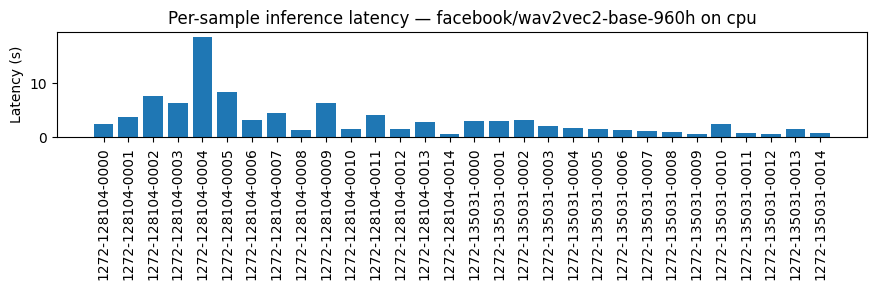

In [19]:
import matplotlib.pyplot as plt

df = pd.DataFrame(rows)
plt.figure(figsize=(9, 3))
plt.bar(df["audio_id"].astype(str), df["latency_sec"])
plt.xticks(rotation=90)
plt.ylabel("Latency (s)")
plt.title(f"Per-sample inference latency — {MODEL_NAME} on {device}")
plt.tight_layout()
plt.show()


## 4. Reproducibility

Everything above is also implemented as a standalone script so the whole
pipeline can be reproduced with a single command, without opening a
notebook:

```bash
pip install -r requirements.txt
python run.py
```

`run.py` (using the modules in `src/`) performs the exact same steps as this
notebook — load model → load dataset → run inference → save
`predictions.csv` → compute metrics → save `metrics.json` and `report.md` —
and accepts CLI flags to change the model / sample count / dataset, e.g.:

```bash
python run.py --model openai/whisper-small --num_samples 40
```

### Final check: confirm all deliverables exist


In [20]:
import os

expected = [
    "results/predictions.csv",
    "results/metrics.json",
    "results/report.md",
]
for path in expected:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else 0
    print(f"{'FOUND ' if exists else 'MISSING'}  {path}  ({size} bytes)")


FOUND   results/predictions.csv  (6738 bytes)
FOUND   results/metrics.json  (331 bytes)
FOUND   results/report.md  (3873 bytes)
